# Neutron Star Mass Distributions

This notebook fits mass distributions to different sub-sets of neutron star data. In particular, we use either a uniform, single gaussian, or double gaussian model with uniform priors on galactic double neutron stars, Gaia neutron stars, and neutron stars in binaries with white dwarves.

In [1]:
import jax.numpy as jnp
import jax.random as random
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, log_likelihood
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats
import corner
import pandas as pd

import seaborn as sns
sns.set_context("paper", font_scale=1.5)


/Users/aryannaschiebelbein/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Model Functions

In [2]:
priormin = 0
priormax = 2.1

In [3]:
def uniform(data, err, prior=False):
    """
    Uniform model with uniform priors.

    Parameters:
        data : array-like
            Observed data.
        err : array-like
            Observed errors.
        prior : bool
            If True, only sample from the prior distribution.   
    """
    low = numpyro.sample("low", dist.Uniform(1, 1.3))
    high = numpyro.sample("high", dist.Uniform(1.5, 1.8))

    if not prior:
        # Soft constraint: all data should be within [low, high]
        penalty = jnp.where((data >= low) & (data <= high), 0.0, -1e6)
        numpyro.factor("in_bounds", jnp.sum(penalty))

        #with numpyro.plate("data", data.shape[0]):
        numpyro.sample("obs", dist.Uniform(low, high), obs=data)

def gaussian_uniform(data, err, prior=False):
    """
    Single Gaussian model with uniform priors.

    Parameters:
        data : array-like
            Observed data.
        err : array-like
            Observed errors.
        prior : bool
            If True, only sample from the prior distribution.
    """
    mu = numpyro.sample('mu', dist.Uniform(priormin, priormax))
    sigma = numpyro.sample('sigma', dist.Uniform(priormin, priormax))
    
    if not prior:
        numpyro.sample('obs', dist.Normal(mu, jnp.sqrt(sigma**2 + err**2)), obs=data)

def double_gaussian_uniform(data, err, prior=False):
    """
    Double Gaussian model with uniform priors.
    
    Parameters:
        data : array-like
            Observed data.
        err : array-like
            Observed errors.
        prior : bool
            If True, only sample from the prior distribution.
    """
    mu1 = numpyro.sample('mu1', dist.Uniform(priormin, priormax))
    mu2 = numpyro.sample('mu2', dist.Uniform(mu1, priormax))
    sigma1 = numpyro.sample('sigma1', dist.Uniform(priormin,priormax))
    sigma2 = numpyro.sample('sigma2', dist.Uniform(priormin, priormax))
    weight = numpyro.sample('weight', dist.Uniform(0, 1)) # only goes up to 0.5 so that there isn't a reversal of the two gaussians

    if not prior:
        scale1 = jnp.sqrt(sigma1**2 + err**2)
        scale2 = jnp.sqrt(sigma2**2 + err**2)

        logp1 = dist.Normal(mu1, scale1).log_prob(data)
        logp2 = dist.Normal(mu2, scale2).log_prob(data)

        log_mix = jnp.logaddexp(jnp.log(weight) + logp1,
                                jnp.log1p(-weight) + logp2)
        numpyro.factor("obs", jnp.sum(log_mix))

In [4]:
def run_inference(model, data, err, rng_key, num_warmup=10000, num_samples=10000):
    """
    Run MCMC inference using the NUTS sampler.  

    Parameters:
        model : callable
            The mass distribution model to sample from.
        data : array-like
            Observed data.
        err : array-like
            Observed errors.
        rng_key : jax.random.PRNGKey
            Random key for JAX.
        num_warmup : int
            Number of warmup samples.
        num_samples : int
            Number of samples to draw from the posterior.
    Returns:
        mcmc : MCMC
            The MCMC object containing the samples.
    """
    kernel = NUTS(model)
    mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples)
    mcmc.run(rng_key, data=data, err=err)
    return mcmc

In [5]:
def plot_mass_distributions(mcmc, model_type, data, label):
    """
    Plots the inferred mass distributions of the parameters.

    Parameters:
        mcmc: MCMC object containing posterior samples.
        model_type: Type of model used ("single" or "double").
        data: The observed data used to define the x-axis range.
        label: Label for the plot.

    Returns:
        Plots of the inferred mass distributions.
    """
    samples = mcmc.get_samples()
    x = np.linspace(min(data) - 0.2, max(data) + 0.2, 1000)

    plt.figure(figsize=(8, 5))

    if model_type == "single":
        mu = samples['mu']
        sigma = samples['sigma']
        for i in np.random.choice(len(mu), 100, replace=False):
            y = scipy.stats.norm.pdf(x, loc=mu[i], scale=sigma[i])  
            plt.plot(x, y, alpha=0.1, color='C0')
    
    elif model_type == "double":
        mu1 = samples['mu1']
        mu2 = samples['mu2']
        sigma1 = samples['sigma1']
        sigma2 = samples['sigma2']
        weight = samples['weight']

        for i in np.random.choice(len(mu1), 100, replace=False):
            w = weight[i]
            y = (
                w * scipy.stats.norm.pdf(x, loc=mu1[i], scale=sigma1[i]) + 
                (1 - w) * scipy.stats.norm.pdf(x, loc=mu2[i], scale=sigma2[i])  
            )
            plt.plot(x, y, alpha=0.1, color='C1')

    plt.xlabel(r"Mass [$M_\odot$]")
    plt.ylabel("PDF")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Load in Data

In [6]:
data = pd.read_csv("NS_data.csv")

DNS = data[data['type'] == 'NS-NS'] # Double neutron star, 'm1' is the recycled neutron star and 'm2' is the slow neutron star
Gaia = data[data['type'] == 'Gaia'] 
NSWD = data[data['type'] == 'NS-WD']

In [7]:
gaia_data = np.array(Gaia['m1'])  
gaia_data_err = np.array(Gaia[['m1_uerr', 'm1_lerr']].max(axis=1).dropna())  

DNS_data = DNS['m1'].dropna().to_numpy()
DNS_data_err = DNS[['m1_uerr', 'm1_lerr']].max(axis=1).dropna().to_numpy()

NSWD_data =  NSWD['m1'].dropna().to_numpy()
NSWD_data_err =NSWD[['m1_uerr', 'm1_lerr']].max(axis=1).dropna().to_numpy()


def plot_cdf(m, uerr, lerr):
    """
    Returns useful arrays to plot the cumulative distribution function (CDF) of the mass distribution.  
    Parameters:
        m : array-like
            Mass values.
        uerr : array-like
            Upper errors.
        lerr : array-like
            Lower errors.

    Returns:
        masses : array-like
            Sorted mass values.
        uerrors : array-like
            Sorted upper errors.
        lerrors : array-like
            Sorted lower errors.
        bins : list
            List of bins for the histogram.
    """

    sorted_idx = np.argsort(m)
    masses = m[sorted_idx] 
    uerrors = uerr[sorted_idx]
    lerrors = lerr[sorted_idx]
    
    masses = masses[~np.isnan(masses)]
    uerrors = uerrors[~np.isnan(uerrors)]
    lerrors = lerrors[~np.isnan(lerrors)]

    bins = list(masses)
    bins.append(max(masses))
    bins.insert(0,0)
    
    return(masses, uerrors, lerrors, bins)

# Gaia Mass Distribution Fit

sample: 100%|██████████| 2000/2000 [00:00<00:00, 2239.92it/s, 3 steps of size 7.62e-01. acc. prob=0.92]


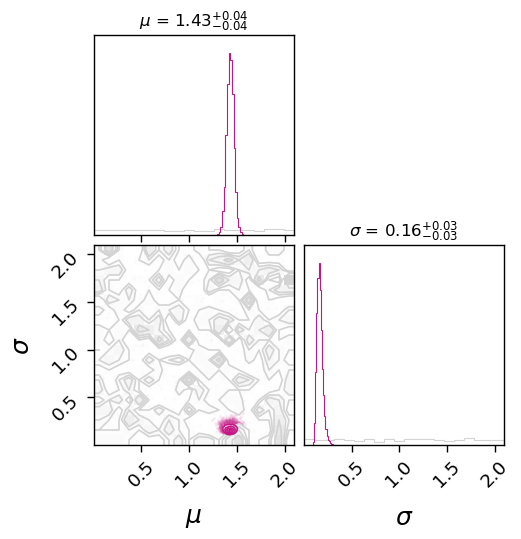

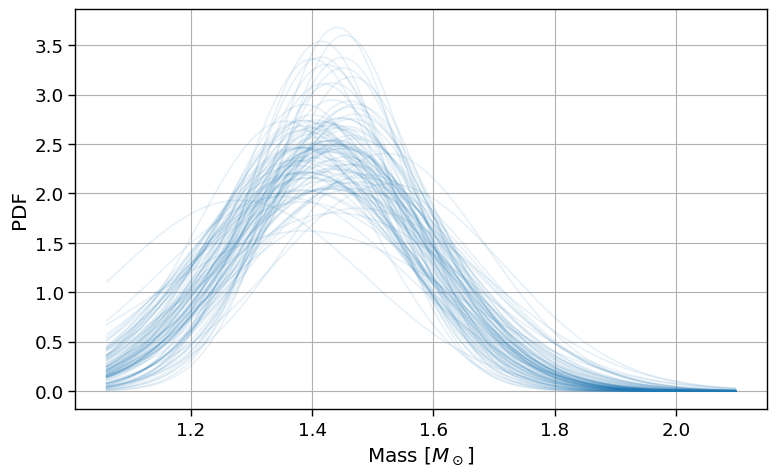

Single Gaussian (Uniform Prior):
logl gaussian_uniform:  1.4121889





sample: 100%|██████████| 2000/2000 [00:01<00:00, 1905.77it/s, 7 steps of size 6.77e-01. acc. prob=0.89]


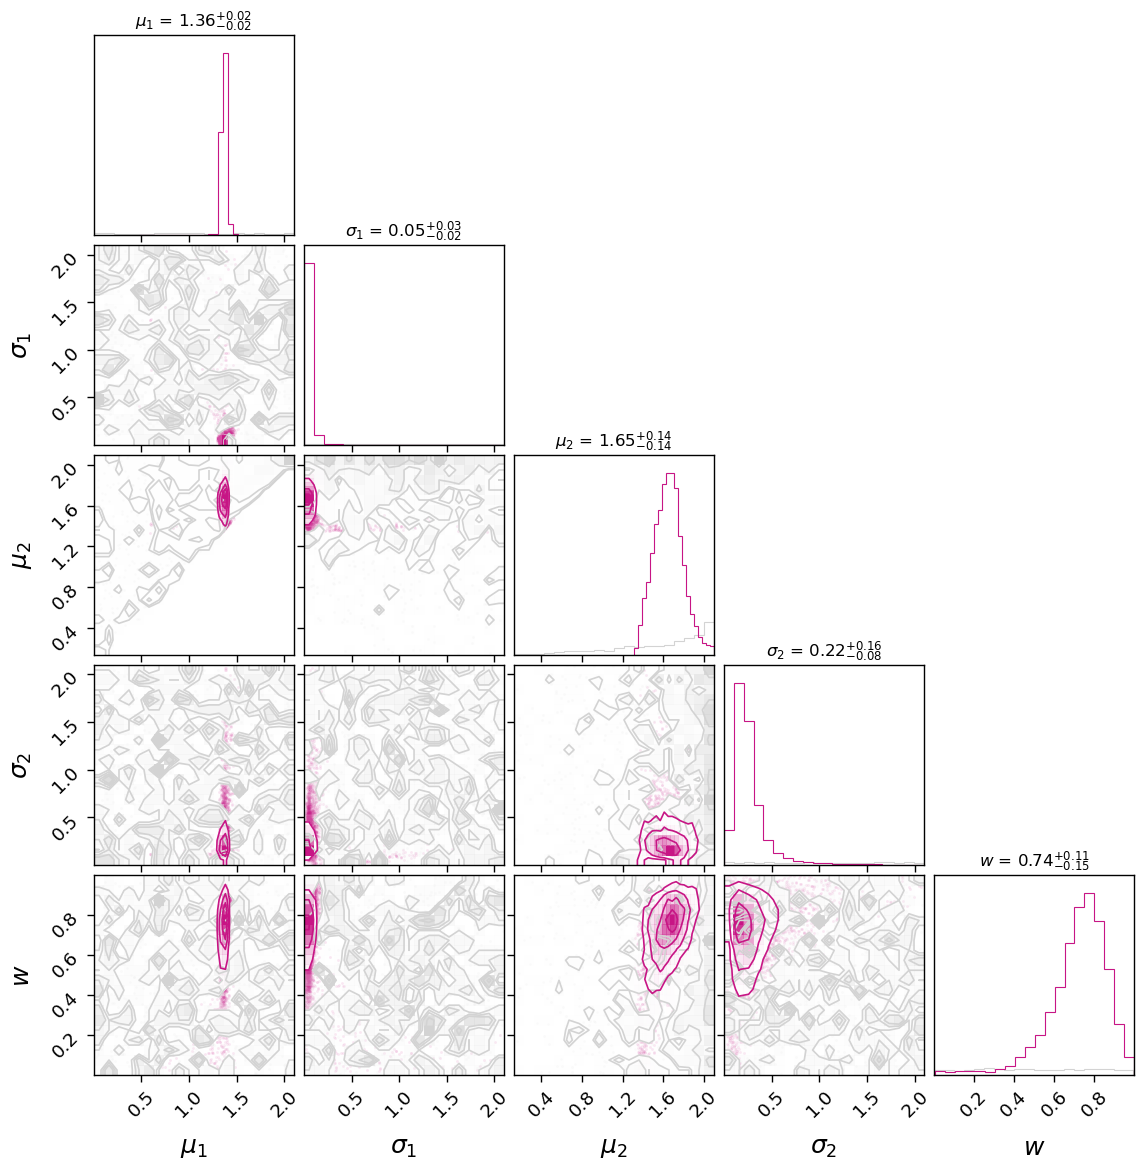

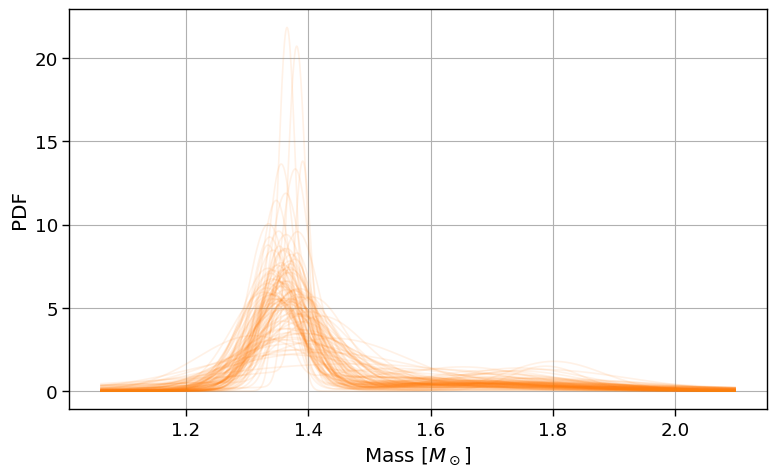

Double Gaussian (Uniform Prior):
logl double_uniform:  17.207262






In [8]:
rng = random.PRNGKey(0)

# Fit single Gaussian - uniform prior
rng, rng_infer_single = random.split(rng)
mcmc_gaussian_uniform = run_inference(gaussian_uniform, gaia_data, gaia_data_err, rng_infer_single)
samples_gaussian_uniform= az.from_numpyro(mcmc_gaussian_uniform)

rng, rng_prior_single = random.split(rng)
prior_sampler = MCMC(NUTS(gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(rng_prior_single,gaia_data, gaia_data_err, prior=True)   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='lightgrey',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_gaussian_uniform,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()

plot_mass_distributions(mcmc_gaussian_uniform, "single", gaia_data, label="Gaia")

print("Single Gaussian (Uniform Prior):")
logl_gaussian_uniform = log_likelihood(gaussian_uniform, mcmc_gaussian_uniform.get_samples(), data=gaia_data, err=gaia_data_err)['obs']
print("logl gaussian_uniform: ", np.max(logl_gaussian_uniform))
print()
print()
print()


# Fit two-component Gaussian - Uniform prior
rng, rng_infer_double = random.split(rng)
mcmc_double_uniform = run_inference(double_gaussian_uniform, gaia_data, gaia_data_err, rng_infer_double)
samples_double_uniform = az.from_numpyro(mcmc_double_uniform)

rng, rng_prior_double = random.split(rng)
prior_sampler = MCMC(NUTS(double_gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(rng_prior_double, gaia_data, gaia_data_err, prior=True)   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='lightgrey',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_double_uniform,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()

plot_mass_distributions(mcmc_double_uniform, "double", gaia_data, label="Data")

print("Double Gaussian (Uniform Prior):")
logl_double_uniform = log_likelihood(double_gaussian_uniform, mcmc_double_uniform.get_samples(), data=gaia_data, err=gaia_data_err)['obs']
print("logl double_uniform: ", np.max(logl_double_uniform))   
print()
print()
print()
print()


In [9]:
# save the fits for comparison with the other populations later
gaia_corner_samples = samples_double_uniform

gaiafit = mcmc_double_uniform
gaiafit_samples = gaiafit.get_samples()

gaiafit_single = mcmc_gaussian_uniform
gaiafit_single_samples = gaiafit_single.get_samples()

array([[<Axes: title={'center': 'mu1'}>, <Axes: title={'center': 'mu1'}>],
       [<Axes: title={'center': 'mu2'}>, <Axes: title={'center': 'mu2'}>],
       [<Axes: title={'center': 'sigma1'}>,
        <Axes: title={'center': 'sigma1'}>],
       [<Axes: title={'center': 'sigma2'}>,
        <Axes: title={'center': 'sigma2'}>],
       [<Axes: title={'center': 'weight'}>,
        <Axes: title={'center': 'weight'}>]], dtype=object)

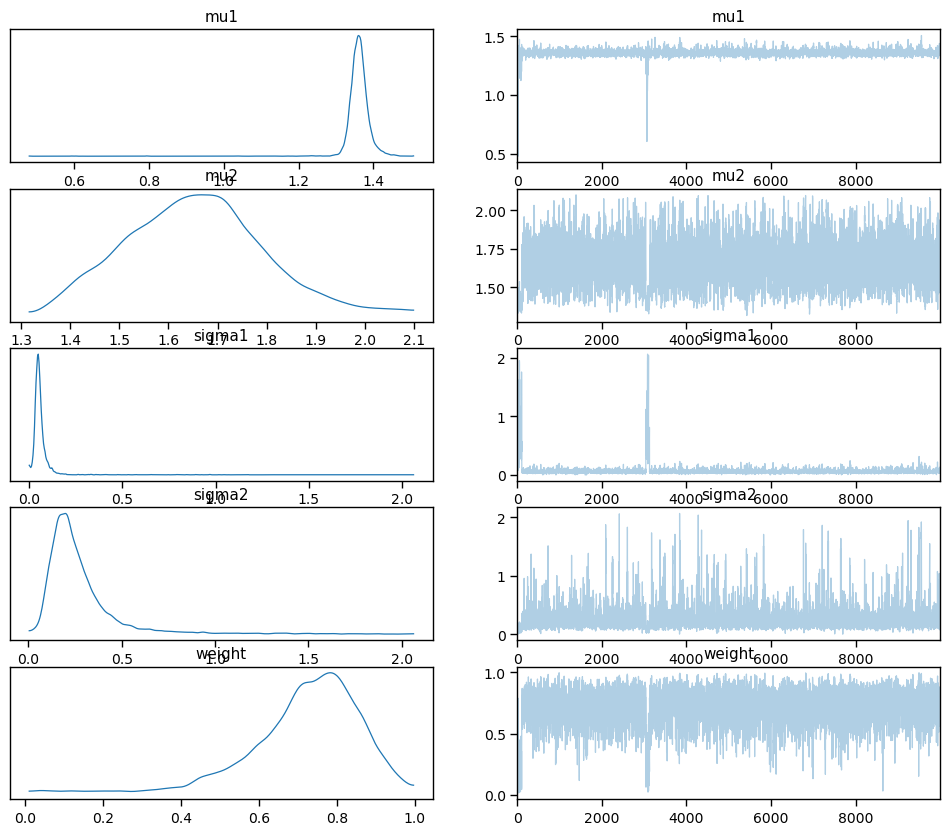

In [10]:
az.plot_trace(gaiafit)

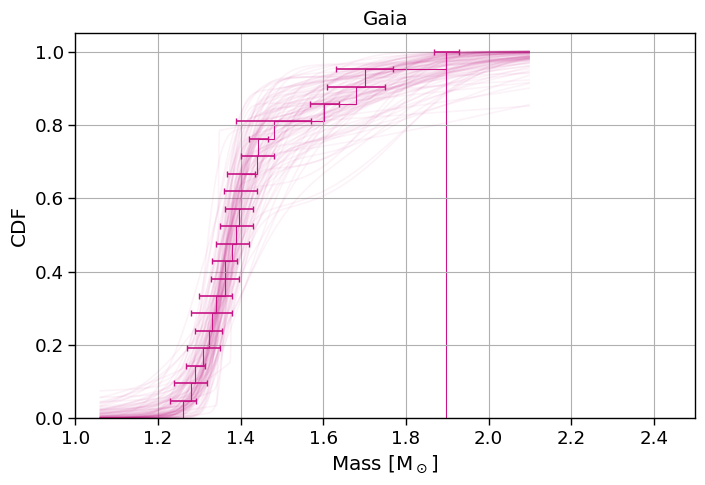

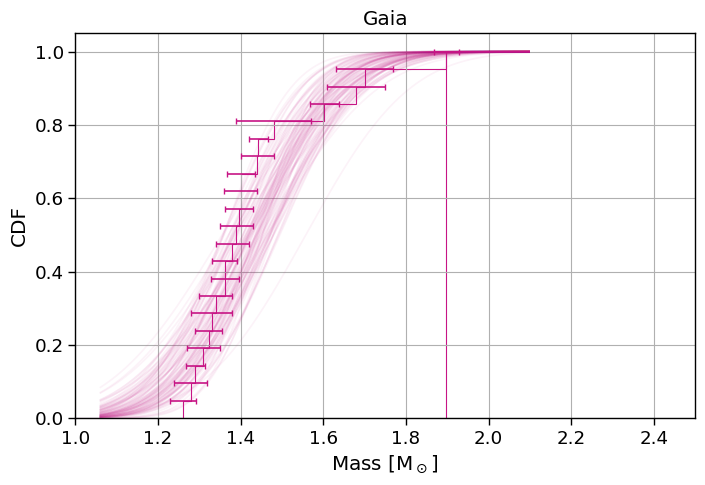

In [11]:
### Plot CDF of fit with data

gaia_masses, gaia_uerrors, gaia_lerrors, gaia_bins = plot_cdf(gaia_data,gaia_data_err,gaia_data_err)

plt.figure(figsize=(8,5))

x = np.linspace(min(gaia_data) - 0.2, max(gaia_data) + 0.2, 1000)

for i in np.random.choice(len(gaiafit_samples['mu1']), 100, replace=False):
    y = gaiafit_samples['weight'][i] * scipy.stats.norm.cdf(
        x, loc=gaiafit_samples['mu1'][i], scale=gaiafit_samples['sigma1'][i]) + (1 - gaiafit_samples['weight'][i]) * scipy.stats.norm.cdf(x, loc=gaiafit_samples['mu2'][i], scale=gaiafit_samples['sigma2'][i])
    plt.plot(x, y, alpha=0.05, color='mediumvioletred', label='Gaia')

plt.stairs(np.array(range(len(gaia_masses)+1))/len(gaia_masses),gaia_bins, alpha =1 ,color='mediumvioletred')
plt.errorbar(gaia_masses, np.array(range(len(gaia_masses)+1))[1:]/len(gaia_masses), xerr = (gaia_uerrors, gaia_lerrors), color='mediumvioletred', ls = "None", capsize = 2)
plt.ylabel("CDF")
plt.xlabel("Mass [M$_\odot$]")
plt.title("Gaia")
plt.xlim(1.0, 2.5)
plt.grid()
plt.show()

plt.figure(figsize=(8,5))
for i in np.random.choice(len(gaiafit_single_samples['mu']), 100, replace=False):
    y = scipy.stats.norm.cdf(x, loc=gaiafit_single_samples['mu'][i], scale=gaiafit_single_samples['sigma'][i])
    plt.plot(x, y, alpha=0.05, color='mediumvioletred', label='Gaia')

plt.stairs(np.array(range(len(gaia_masses)+1))/len(gaia_masses),gaia_bins, alpha =1 ,color='mediumvioletred')
plt.errorbar(gaia_masses, np.array(range(len(gaia_masses)+1))[1:]/len(gaia_masses), xerr = (gaia_uerrors, gaia_lerrors), color='mediumvioletred', ls = "None", capsize = 2)

plt.ylabel("CDF")
plt.xlabel("Mass [M$_\odot$]")
plt.title("Gaia")
plt.xlim(1.0, 2.5)
plt.grid()
plt.show()

# Recycled NS

sample: 100%|██████████| 2000/2000 [00:00<00:00, 2461.95it/s, 3 steps of size 7.62e-01. acc. prob=0.92]


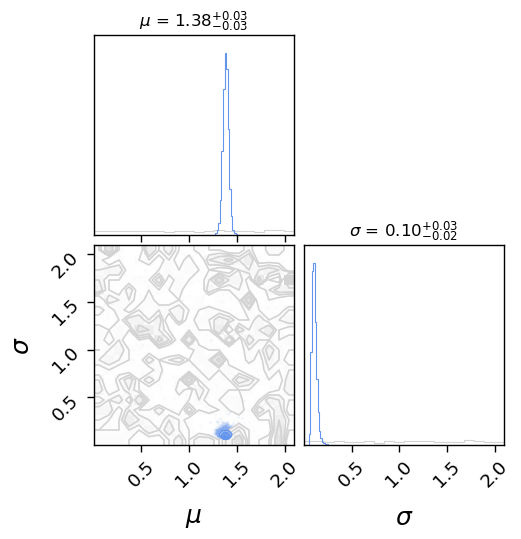

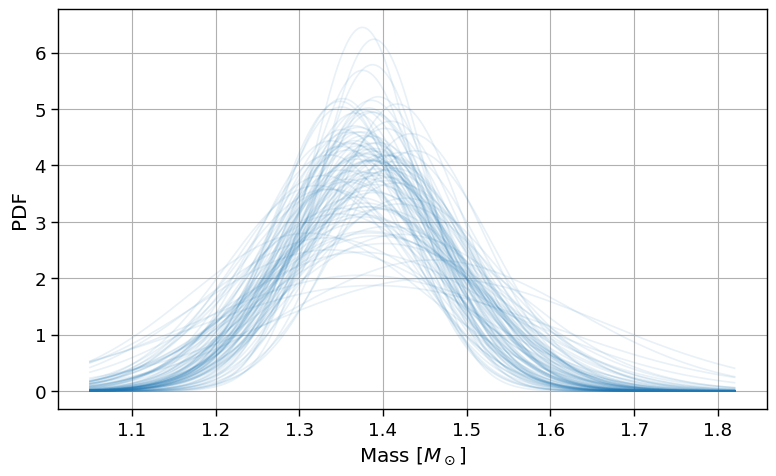

Single Gaussian (Uniform Prior):
logl gaussian_uniform:  1.9797146





sample: 100%|██████████| 2000/2000 [00:01<00:00, 1425.96it/s, 7 steps of size 6.77e-01. acc. prob=0.89]


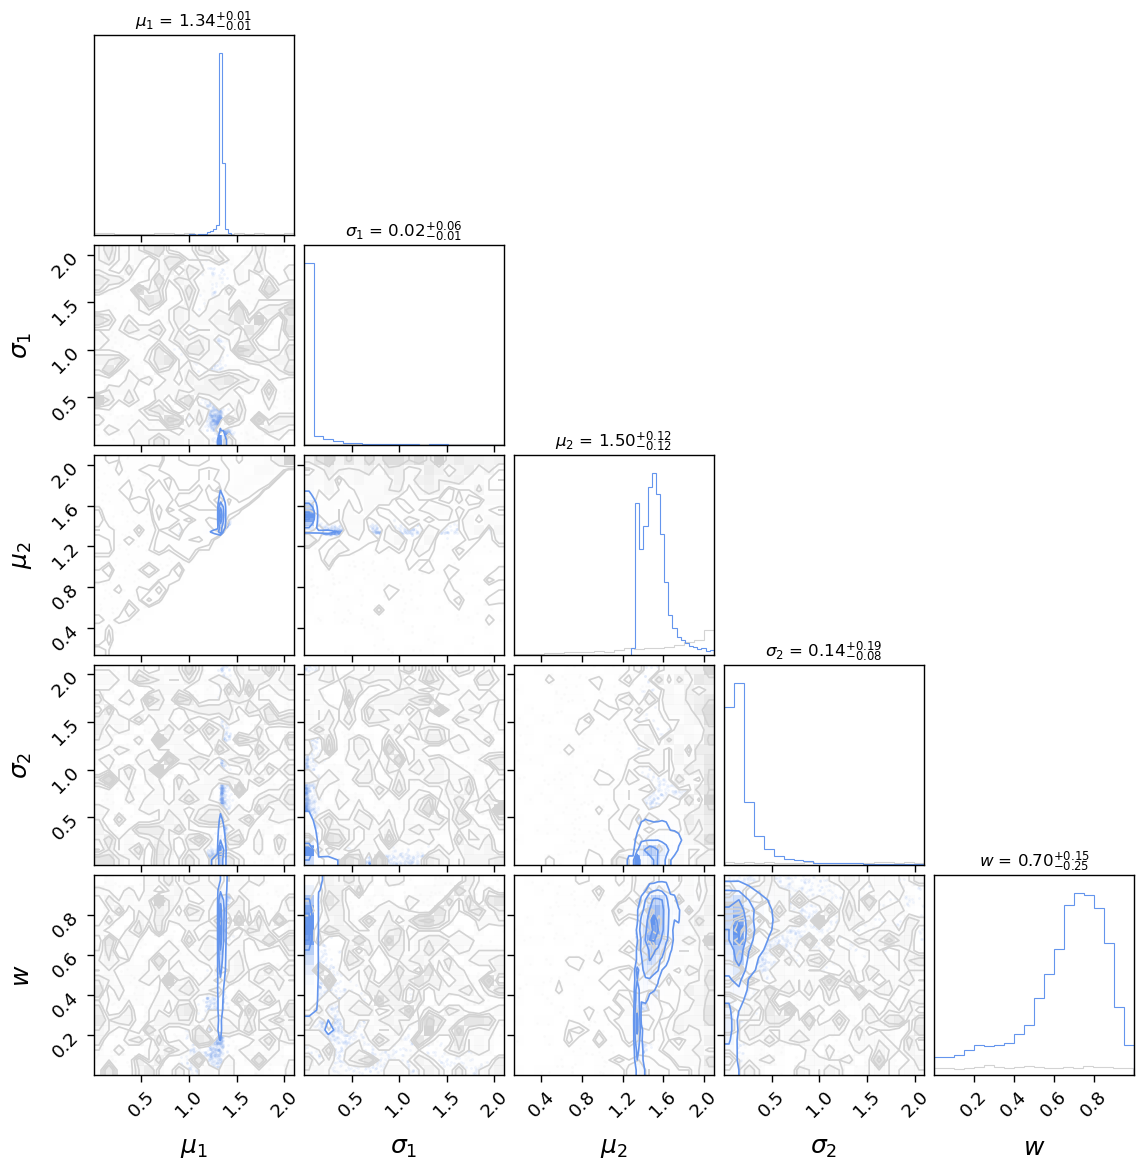

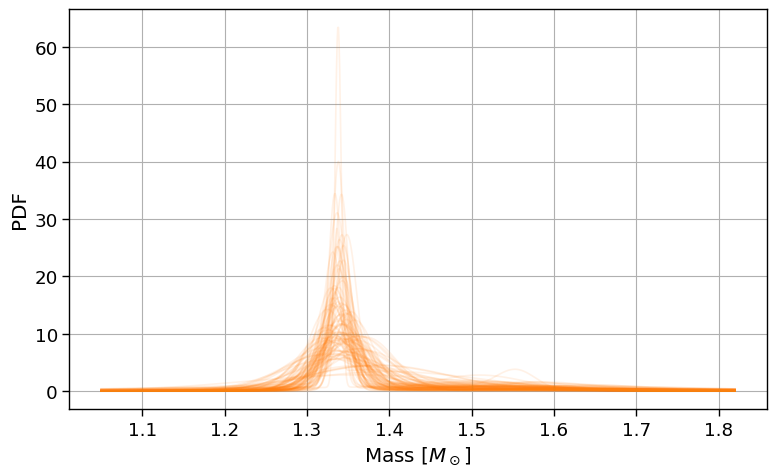

Double Gaussian (Uniform Prior):
logl double_uniform:  21.059195





In [12]:
rng = random.PRNGKey(0)

# Fit single Gaussian - uniform prior
rng, rng_infer_single = random.split(rng)
mcmc_gaussian_uniform = run_inference(gaussian_uniform, DNS_data, DNS_data_err, rng_infer_single)
samples_gaussian_uniform= az.from_numpyro(mcmc_gaussian_uniform)

rng, rng_prior_single = random.split(rng)
prior_sampler = MCMC(NUTS(gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(rng_prior_single,DNS_data, DNS_data_err, prior=True)   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='lightgrey',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_gaussian_uniform,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='cornflowerblue',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

plt.show()

plot_mass_distributions(mcmc_gaussian_uniform, "single", DNS_data, label="Recycled NS")

print("Single Gaussian (Uniform Prior):")
logl_gaussian_uniform = log_likelihood(gaussian_uniform, mcmc_gaussian_uniform.get_samples(), data=DNS_data, err=DNS_data_err)['obs']
print("logl gaussian_uniform: ", np.max(logl_gaussian_uniform))
print()
print()
print()

# Fit two-component Gaussian - Uniform prior
rng, rng_infer_double = random.split(rng)
mcmc_double_uniform = run_inference(double_gaussian_uniform, DNS_data, DNS_data_err, rng_infer_double)
samples_double_uniform = az.from_numpyro(mcmc_double_uniform)

rng
prior_sampler = MCMC(NUTS(double_gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(rng_prior_double, DNS_data, DNS_data_err, prior=True)   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='lightgrey',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_double_uniform,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='cornflowerblue',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()

plot_mass_distributions(mcmc_double_uniform, "double", DNS_data, label="Recycled NS")

print("Double Gaussian (Uniform Prior):")
logl_double_uniform = log_likelihood(double_gaussian_uniform, mcmc_double_uniform.get_samples(), data=DNS_data, err=DNS_data_err)['obs']
print("logl double_uniform: ", np.max(logl_double_uniform))   
print()
print()
print()

In [13]:
# Save the fits for comparison with the other populations later
DNS_corner_samples = samples_double_uniform

recycledDNSfit = mcmc_double_uniform
recycledDNSfit_samples = recycledDNSfit.get_samples()

recycledDNSfit_single = mcmc_gaussian_uniform
recycledDNSfit_single_samples = recycledDNSfit_single.get_samples()

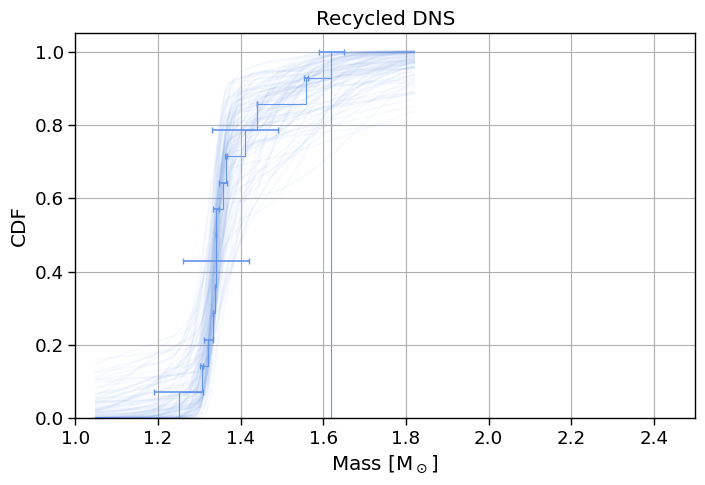

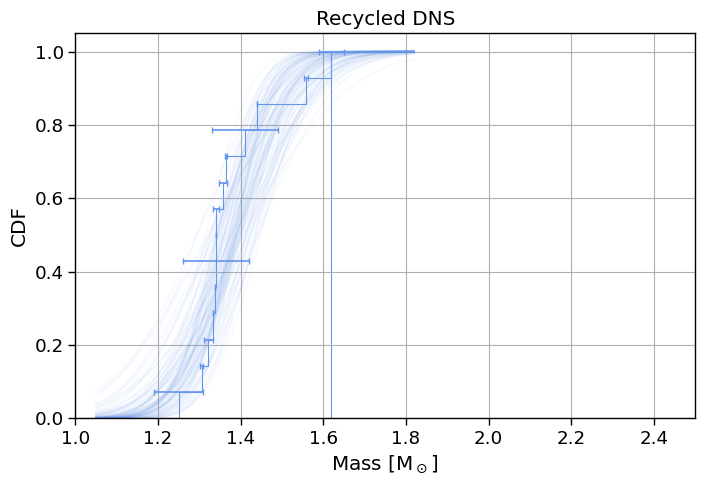

In [14]:
# Plot CDF of fit with data

DNS_masses, DNS_uerrors, DNS_lerrors, DNS_bins =plot_cdf(DNS_data,DNS_data_err,DNS_data_err)

x = np.linspace(min(DNS_data) - 0.2, max(DNS_data) + 0.2, 1000)

fig = plt.figure(figsize=(8,5))
for i in np.random.choice(len(recycledDNSfit_samples['mu1']), 100, replace=False):
    y = recycledDNSfit_samples['weight'][i] * scipy.stats.norm.cdf(
        x, loc=recycledDNSfit_samples['mu1'][i], scale=recycledDNSfit_samples['sigma1'][i]  
    ) + (1 - recycledDNSfit_samples['weight'][i]) * scipy.stats.norm.cdf(
        x, loc=recycledDNSfit_samples['mu2'][i], scale=recycledDNSfit_samples['sigma2'][i]  
    )
    plt.plot(x, y, alpha=0.05, color='cornflowerblue', label='Recycled DNS')

plt.stairs(np.array(range(len(DNS_masses)+1))/len(DNS_masses),DNS_bins, alpha =1 ,color='cornflowerblue')
plt.errorbar(DNS_masses, np.array(range(len(DNS_masses)+1))[1:]/len(DNS_masses), xerr = (DNS_uerrors, DNS_lerrors), color='cornflowerblue', ls = "None", capsize = 2)
plt.ylabel("CDF")
plt.xlabel("Mass [M$_\odot$]")
plt.title("Recycled DNS")
plt.xlim(1.0, 2.5)
plt.grid()
plt.show()

fig = plt.figure(figsize=(8,5))
for i in np.random.choice(len(recycledDNSfit_single_samples['mu']), 100, replace=False):
    y =  scipy.stats.norm.cdf(x, loc=recycledDNSfit_single_samples['mu'][i], scale=recycledDNSfit_single_samples['sigma'][i])
    plt.plot(x, y, alpha=0.05, color='cornflowerblue', label='Recycled DNS')

plt.stairs(np.array(range(len(DNS_masses)+1))/len(DNS_masses),DNS_bins, alpha =1 ,color='cornflowerblue')
plt.errorbar(DNS_masses, np.array(range(len(DNS_masses)+1))[1:]/len(DNS_masses), xerr = (DNS_uerrors, DNS_lerrors), color='cornflowerblue', ls = "None", capsize = 2)
plt.ylabel("CDF")
plt.xlabel("Mass [M$_\odot$]")
plt.title("Recycled DNS")
plt.xlim(1.0, 2.5)
plt.grid()
plt.show()




# Slow Neutron Stars

sample: 100%|██████████| 2000/2000 [00:00<00:00, 2196.35it/s, 3 steps of size 7.98e-01. acc. prob=0.91]


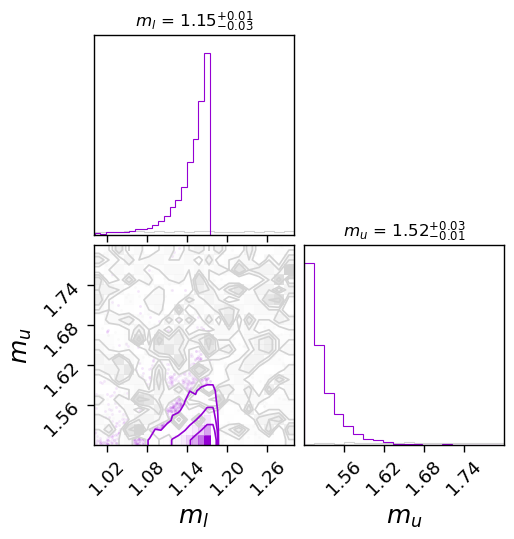

Uniform Distribution:
logl uniform:  1.1176656





sample: 100%|██████████| 2000/2000 [00:00<00:00, 2304.89it/s, 3 steps of size 8.19e-01. acc. prob=0.90]


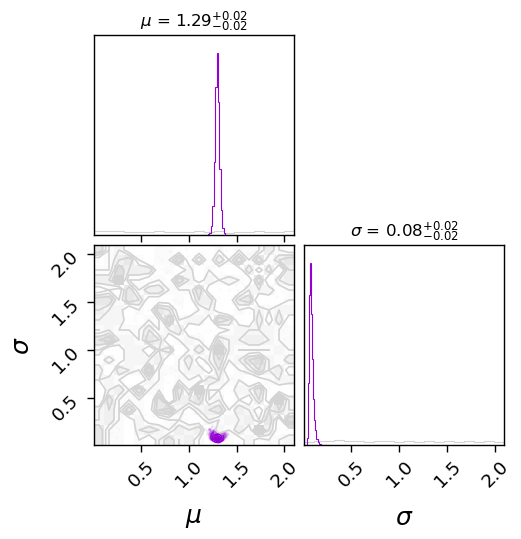

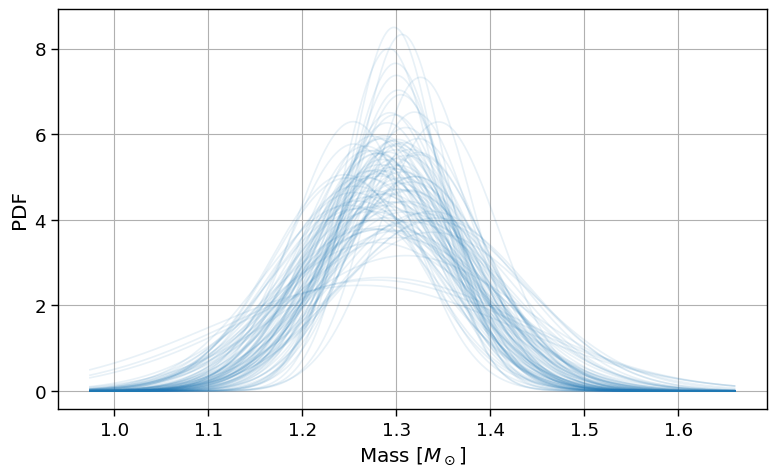

Single Gaussian (Uniform Prior):
logl gaussian_uniform:  2.3153355





sample: 100%|██████████| 2000/2000 [00:01<00:00, 1984.42it/s, 7 steps of size 7.47e-01. acc. prob=0.87]


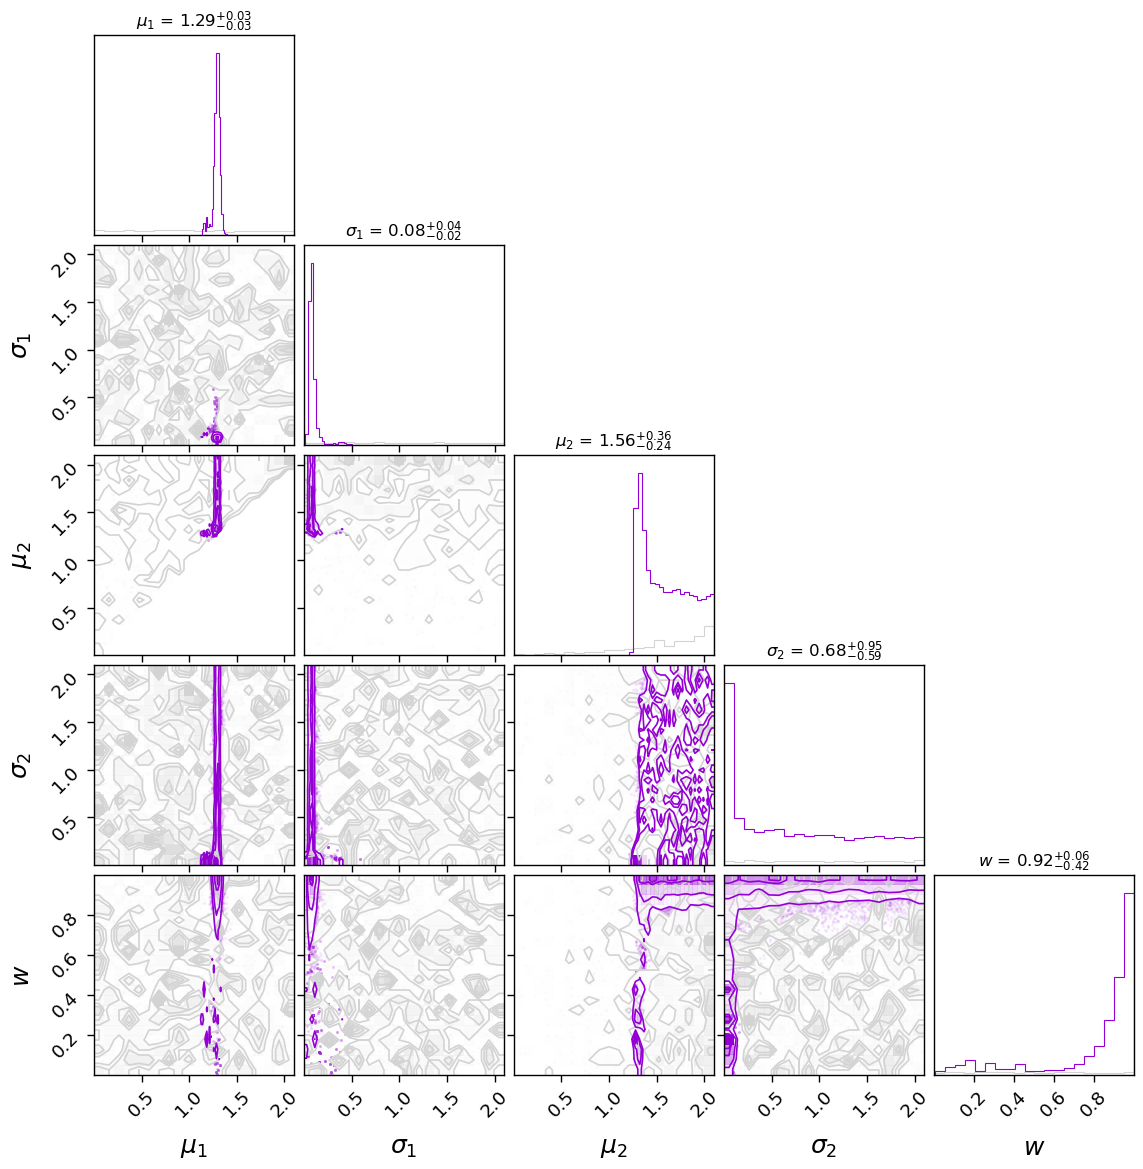

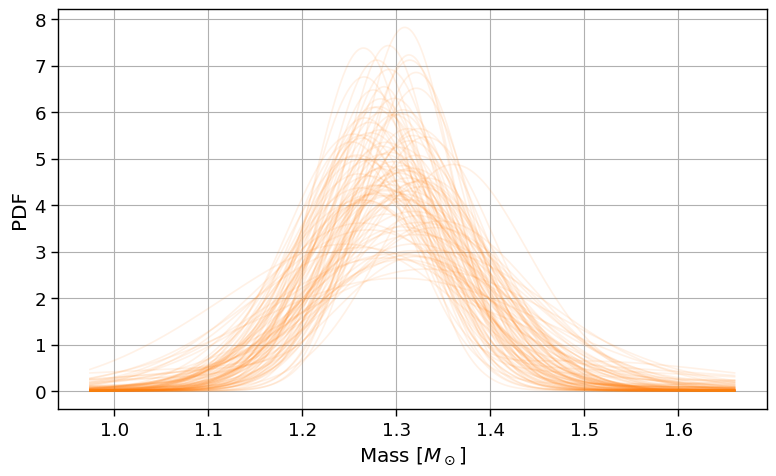

Double Gaussian (Uniform Prior):
logl double_uniform:  17.401829






In [16]:
slow_data = DNS['m2'].dropna().to_numpy()
slow_data_err = DNS[['m2_uerr', 'm2_lerr']].max(axis=1).dropna().to_numpy()

rng = random.PRNGKey(0)

#Fit uniform distribution - uniform prior
rng, rng_infer_uniform = random.split(rng)
mcmc_uniform = run_inference(uniform, slow_data, slow_data_err, rng_infer_uniform)
samples_uniform = az.from_numpyro(mcmc_uniform)

rng, rng_prior_uniform = random.split(rng)
prior_sampler = MCMC(NUTS(uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(rng_prior_uniform, slow_data, slow_data_err, prior=True)
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['low', 'high'],
    labels=[r"$m_l$", r"$m_u$"],
    color='lightgrey',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
corner.corner(
    samples_uniform,
    var_names=['low', 'high'],
    labels=[r"$m_l$", r"$m_u$"],
    color='darkviolet',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()

print("Uniform Distribution:")
logl_uniform = log_likelihood(uniform, mcmc_uniform.get_samples(), data=slow_data, err=slow_data_err)['obs']
print("logl uniform: ", np.max(logl_uniform))
print()
print()
print()

# Fit single Gaussian - uniform prior
rng, rng_infer_single = random.split(rng)
mcmc_gaussian_uniform = run_inference(gaussian_uniform, slow_data, slow_data_err, rng_infer_single)
samples_gaussian_uniform= az.from_numpyro(mcmc_gaussian_uniform)

rng, rng_prior_single = random.split(rng)
prior_sampler = MCMC(NUTS(gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(rng_prior_single, slow_data, slow_data_err, prior=True)   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='lightgrey',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_gaussian_uniform,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='darkviolet',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

plt.show()

#corner_plot(mcmc_gaussian_uniform, "single", "Posterior: Single Gaussian - Uniform Prior")
plot_mass_distributions(mcmc_gaussian_uniform, "single", slow_data, label="Slow NS")

print("Single Gaussian (Uniform Prior):")
logl_gaussian_uniform = log_likelihood(gaussian_uniform, mcmc_gaussian_uniform.get_samples(), data=slow_data, err=slow_data_err)['obs']
print("logl gaussian_uniform: ", np.max(logl_gaussian_uniform))
print()
print()
print()


# Fit two-component Gaussian - Uniform prior
rng, rng_infer_double = random.split(rng)
mcmc_double_uniform = run_inference(double_gaussian_uniform, slow_data, slow_data_err, rng_infer_double)
samples_double_uniform = az.from_numpyro(mcmc_double_uniform)

rng, rng_prior_double = random.split(rng)
prior_sampler = MCMC(NUTS(double_gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(rng_prior_double, slow_data, slow_data_err, prior=True)   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='lightgrey',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_double_uniform,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='darkviolet',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()

#corner_plot(mcmc_double_uniform, "double", "Posterior: Two-Gaussian Mixture - Uniform Prior")
plot_mass_distributions(mcmc_double_uniform, "double", slow_data, label="Slow NS")

print("Double Gaussian (Uniform Prior):")
logl_double_uniform = log_likelihood(double_gaussian_uniform, mcmc_double_uniform.get_samples(), data=slow_data, err=slow_data_err)['obs']
print("logl double_uniform: ", np.max(logl_double_uniform))   
print()
print()
print()
print()

In [17]:
# save the fits for comparison with the other populations later
slow_corner_samples = samples_double_uniform
slowDNSfit = mcmc_uniform
slowDNSfit_samples = slowDNSfit.get_samples()

array([[<Axes: title={'center': 'high'}>,
        <Axes: title={'center': 'high'}>],
       [<Axes: title={'center': 'low'}>, <Axes: title={'center': 'low'}>]],
      dtype=object)

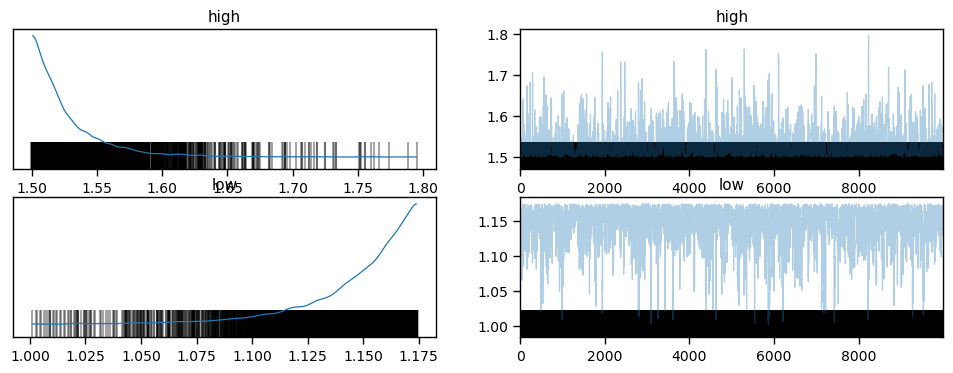

In [18]:
az.plot_trace(slowDNSfit)

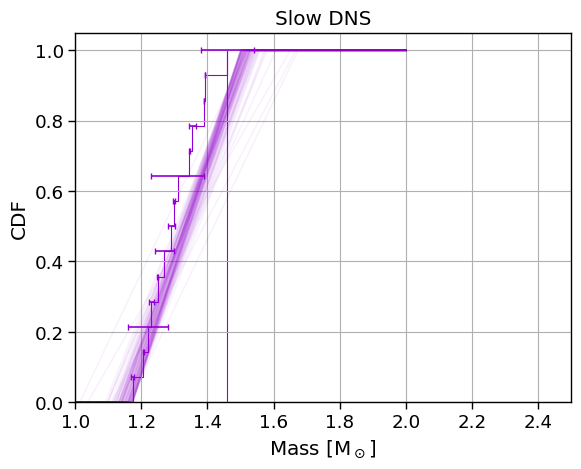

In [19]:
#Plot CDF of fit with data

slow_masses, slow_uerrors, slow_lerrors, slow_bins =plot_cdf(slow_data,slow_data_err,slow_data_err)

x = np.linspace(1,2, 1000)

for i in np.random.choice(len(slowDNSfit_samples['low']), 100, replace=False):
    y = scipy.stats.uniform.cdf(x, loc=slowDNSfit_samples['low'][i], scale=slowDNSfit_samples['high'][i] - slowDNSfit_samples['low'][i])
    
    plt.plot(x, y, alpha=0.05, color='darkviolet', label='Slow DNS')

plt.stairs(np.array(range(len(slow_masses)+1))/len(slow_masses),slow_bins, alpha =1 ,color='darkviolet')
plt.errorbar(slow_masses, np.array(range(len(slow_masses)+1))[1:]/len(slow_masses), xerr = (slow_uerrors, slow_lerrors), color='darkviolet', ls = "None", capsize = 2)
plt.ylabel("CDF")
plt.xlabel("Mass [M$_\odot$]")
plt.title("Slow DNS")
plt.xlim(1.0, 2.5)
plt.grid()
plt.show()

# NS-WD

sample: 100%|██████████| 2000/2000 [00:01<00:00, 1906.96it/s, 3 steps of size 7.62e-01. acc. prob=0.92]


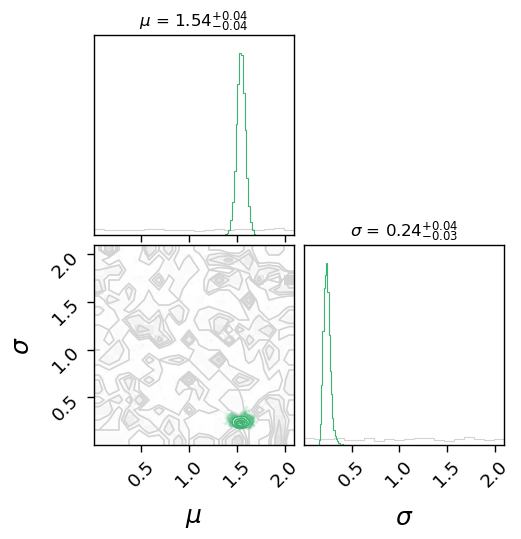

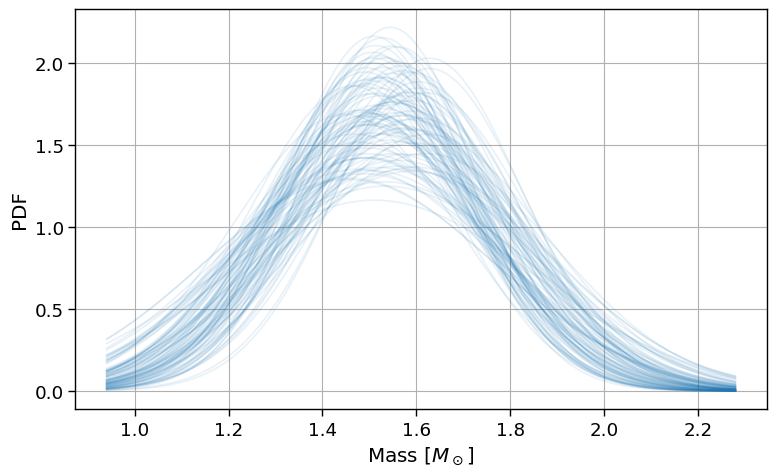

Single Gaussian (Uniform Prior):
logl gaussian_uniform:  0.93267876





sample: 100%|██████████| 2000/2000 [00:01<00:00, 1565.06it/s, 7 steps of size 6.77e-01. acc. prob=0.89]


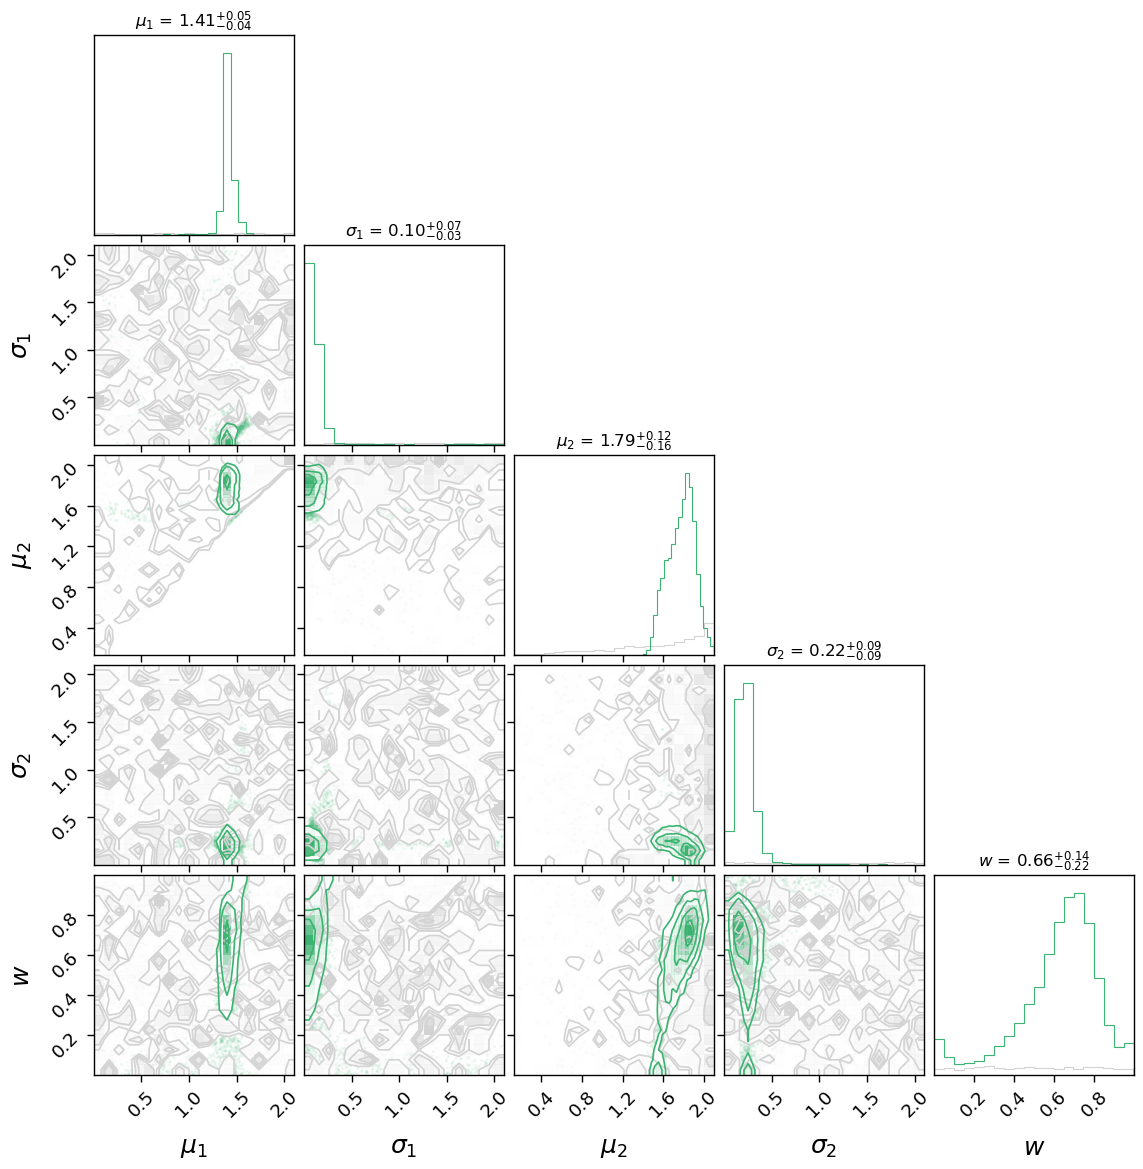

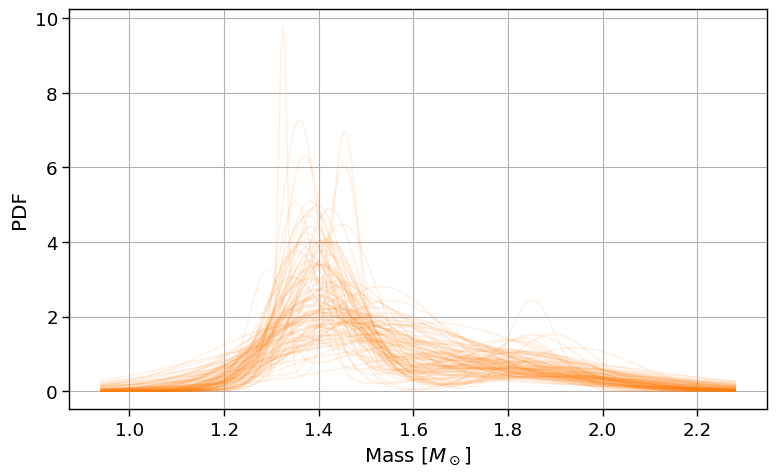

Double Gaussian (Uniform Prior):
logl double_uniform:  3.027292






In [20]:
rng = random.PRNGKey(0)

# Fit single Gaussian - uniform prior
rng, rng_infer_single = random.split(rng)
mcmc_gaussian_uniform = run_inference(gaussian_uniform, NSWD_data, NSWD_data_err, rng_infer_single)
samples_gaussian_uniform= az.from_numpyro(mcmc_gaussian_uniform)

rng, rng_prior_single = random.split(rng)
prior_sampler = MCMC(NUTS(gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(rng_prior_single, NSWD_data, NSWD_data_err, prior=True)   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='lightgrey',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_gaussian_uniform,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='mediumseagreen',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

plt.show()

plot_mass_distributions(mcmc_gaussian_uniform, "single", NSWD_data, label="NS-WD")

print("Single Gaussian (Uniform Prior):")
logl_gaussian_uniform = log_likelihood(gaussian_uniform, mcmc_gaussian_uniform.get_samples(), data=NSWD_data, err=NSWD_data_err)['obs']
print("logl gaussian_uniform: ", np.max(logl_gaussian_uniform))
print()
print()
print()


# Fit two-component Gaussian - Uniform prior
rng, rng_infer_double = random.split(rng)
mcmc_double_uniform = run_inference(double_gaussian_uniform, NSWD_data, NSWD_data_err, rng_infer_double)
samples_double_uniform = az.from_numpyro(mcmc_double_uniform)

rng, rng_prior_double = random.split(rng)
prior_sampler = MCMC(NUTS(double_gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(rng_prior_double, NSWD_data, NSWD_data_err, prior=True)   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='lightgrey',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_double_uniform,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='mediumseagreen',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()

plot_mass_distributions(mcmc_double_uniform, "double", NSWD_data, label="NS-WD")

print("Double Gaussian (Uniform Prior):")
logl_double_uniform = log_likelihood(double_gaussian_uniform, mcmc_double_uniform.get_samples(), data=NSWD_data, err=NSWD_data_err)['obs']
print("logl double_uniform: ", np.max(logl_double_uniform))   
print()
print()
print()
print()

In [21]:
# save the fits for comparison with the other populations later
NSWD_corner_samples = samples_double_uniform
NSWDfit = mcmc_double_uniform
NSWDfit_samples = NSWDfit.get_samples()

NSWD_corner_samples = NSWDfit_samples

array([[<Axes: title={'center': 'mu1'}>, <Axes: title={'center': 'mu1'}>],
       [<Axes: title={'center': 'mu2'}>, <Axes: title={'center': 'mu2'}>],
       [<Axes: title={'center': 'sigma1'}>,
        <Axes: title={'center': 'sigma1'}>],
       [<Axes: title={'center': 'sigma2'}>,
        <Axes: title={'center': 'sigma2'}>],
       [<Axes: title={'center': 'weight'}>,
        <Axes: title={'center': 'weight'}>]], dtype=object)

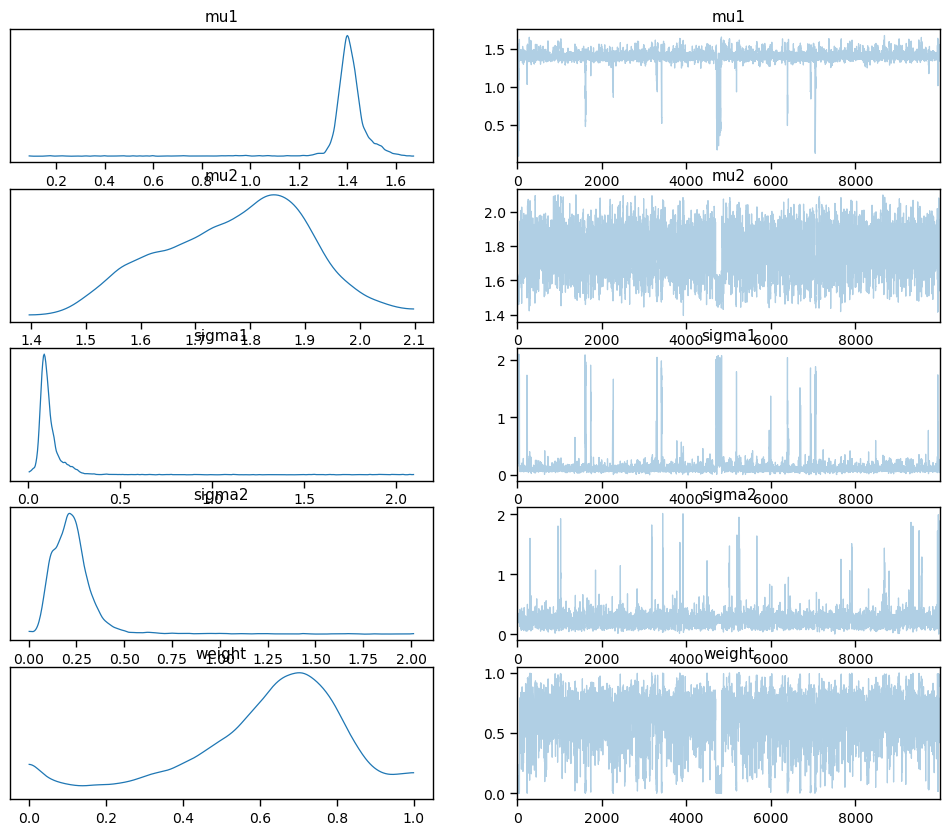

In [22]:
az.plot_trace(NSWDfit)

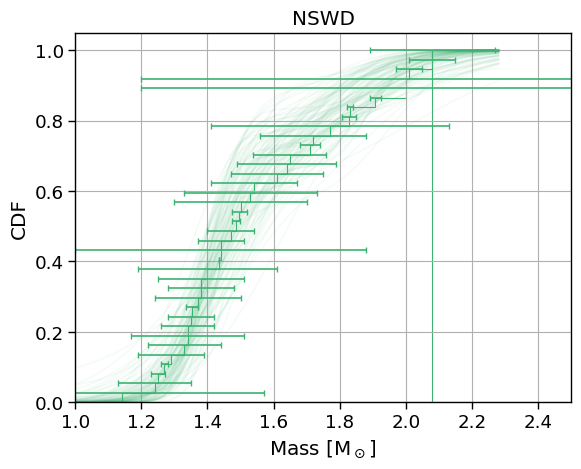

In [23]:
# plot CDF of fit with data
NSWD_masses,NSWD_uerrors, NSWD_lerrors, NSWD_bins =plot_cdf(NSWD_data,NSWD_data_err,NSWD_data_err)


x = np.linspace(min(NSWD_data) - 0.2, max(NSWD_data) + 0.2, 1000)
for i in np.random.choice(len(NSWDfit_samples['mu1']), 100, replace=False):
    y = NSWDfit_samples['weight'][i] * scipy.stats.norm.cdf(
        x, loc=NSWDfit_samples['mu1'][i], scale=NSWDfit_samples['sigma1'][i]  
    ) + (1 - NSWDfit_samples['weight'][i]) * scipy.stats.norm.cdf(
        x, loc=NSWDfit_samples['mu2'][i], scale=NSWDfit_samples['sigma2'][i]  
    )
    plt.plot(x, y, alpha=0.05, color='mediumseagreen', label='NS-WD')


plt.stairs(np.array(range(len(NSWD_masses)+1))/len(NSWD_masses),NSWD_bins, alpha =1 ,color='mediumseagreen')
plt.errorbar(NSWD_masses, np.array(range(len(NSWD_masses)+1))[1:]/len(NSWD_masses), xerr = (NSWD_uerrors, NSWD_lerrors), color='mediumseagreen', ls = "None", capsize = 2)
plt.ylabel("CDF")
plt.xlabel("Mass [M$_\odot$]")
plt.title("NSWD")
plt.xlim(1.0, 2.5)
plt.grid()
plt.show()


# Comparison Tests

/var/folders/by/tlp8gdq17q72kgysbfmtlzp40000gn/T/ipykernel_77531/3373414376.py:33: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend.legendHandles:


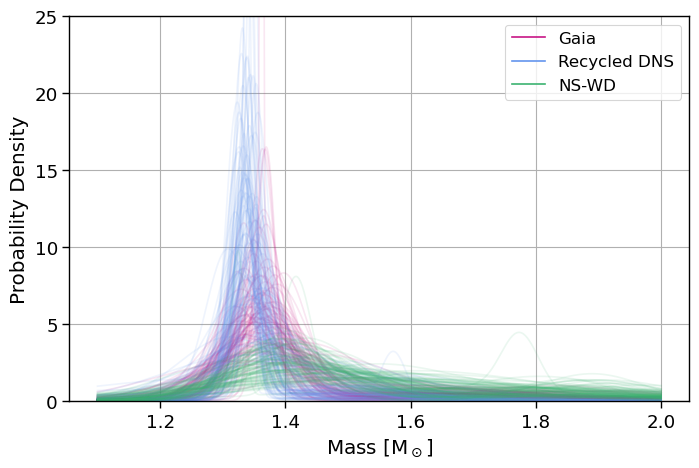

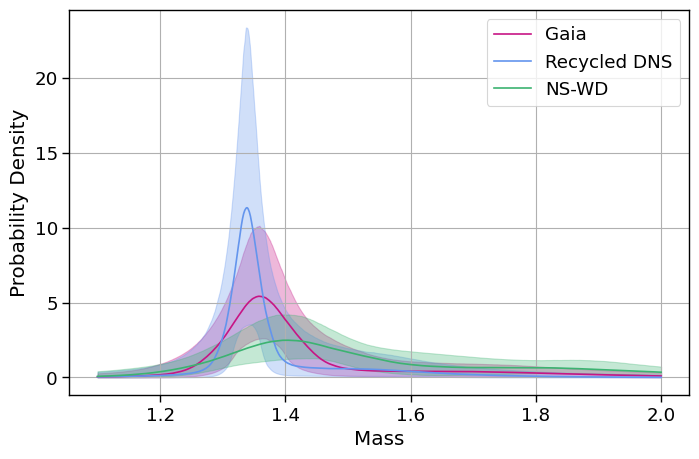

/var/folders/by/tlp8gdq17q72kgysbfmtlzp40000gn/T/ipykernel_77531/3373414376.py:114: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend.legendHandles:


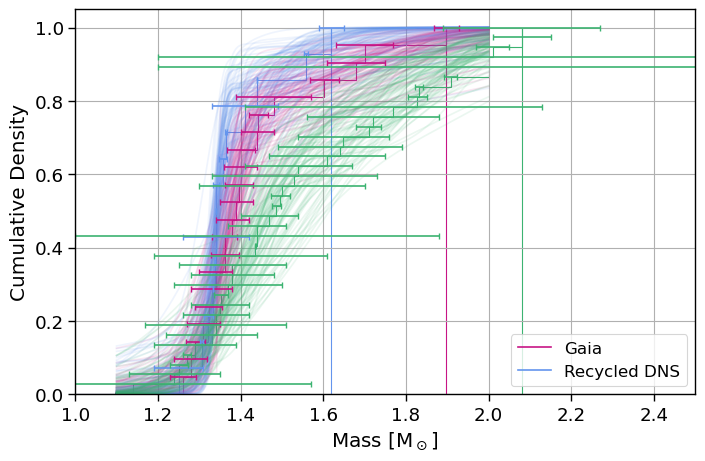

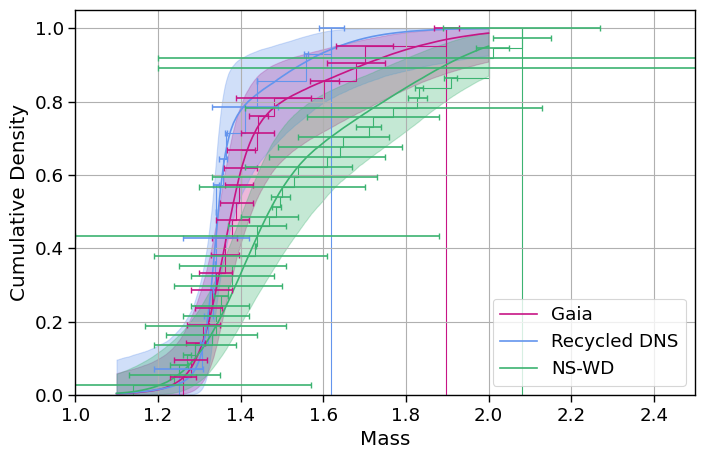

In [24]:
# Plot the mass distributions of the recycled DNS and Gaia populations

plt.figure(figsize=(8,5))
x = np.linspace(1.1, 2, 1000)

plotN = 0
for i in np.random.choice(len(gaiafit_samples['mu1']), 100, replace=False):
    y = gaiafit_samples['weight'][i] * scipy.stats.norm.pdf(x, loc=gaiafit_samples['mu1'][i], scale=gaiafit_samples['sigma1'][i]) +\
        (1 - gaiafit_samples['weight'][i]) * scipy.stats.norm.pdf(x, loc=gaiafit_samples['mu2'][i], scale=gaiafit_samples['sigma2'][i])
    plt.plot(x, y, alpha=0.1, color='mediumvioletred', label='Gaia' if plotN == 0 else None)
    plotN += 1

plotN = 0
for i in np.random.choice(len(recycledDNSfit_samples['mu1']), 100, replace=False):
    y = recycledDNSfit_samples['weight'][i] * scipy.stats.norm.pdf(x, loc=recycledDNSfit_samples['mu1'][i], scale=recycledDNSfit_samples['sigma1'][i]) +\
        (1 - recycledDNSfit_samples['weight'][i]) * scipy.stats.norm.pdf(x, loc=recycledDNSfit_samples['mu2'][i], scale=recycledDNSfit_samples['sigma2'][i])
    plt.plot(x, y, alpha=0.1, color='cornflowerblue', label= 'Recycled DNS' if plotN == 0 else None)
    plotN += 1

plotN = 0

for i in np.random.choice(len(NSWDfit_samples['mu1']), 100, replace=False):
    y = NSWDfit_samples['weight'][i] * scipy.stats.norm.pdf(x, loc=NSWDfit_samples['mu1'][i], scale=NSWDfit_samples['sigma1'][i]) +\
        (1 - NSWDfit_samples['weight'][i]) * scipy.stats.norm.pdf(x, loc=NSWDfit_samples['mu2'][i], scale=NSWDfit_samples['sigma2'][i])
    plt.plot(x, y, alpha=0.1, color='mediumseagreen', label='NS-WD' if plotN == 0 else None)
    plotN += 1

plt.grid()
plt.ylabel("Probability Density")
plt.xlabel("Mass [M$_\odot$]")
plt.ylim(0,25)
legend = plt.legend(frameon=True, loc='best', fontsize=12)
for handle in legend.legendHandles:
    handle.set_alpha(1.0) 
plt.show()
#
#
#

# Plot credible bands instead of individual curves
gaiacurves = np.array([
    gaiafit_samples['weight'][i] * scipy.stats.norm.pdf(x, loc=gaiafit_samples['mu1'][i], scale=gaiafit_samples['sigma1'][i]) +
    (1 - gaiafit_samples['weight'][i]) * scipy.stats.norm.pdf(x, loc=gaiafit_samples['mu2'][i], scale=gaiafit_samples['sigma2'][i])
    for i in range(len(gaiafit_samples['mu1']))
])

recycledDNScurves = np.array([
    recycledDNSfit_samples['weight'][i] * scipy.stats.norm.pdf(x, loc=recycledDNSfit_samples['mu1'][i], scale=recycledDNSfit_samples['sigma1'][i]) +
    (1 - recycledDNSfit_samples['weight'][i]) * scipy.stats.norm.pdf(x, loc=recycledDNSfit_samples['mu2'][i], scale=recycledDNSfit_samples['sigma2'][i])
    for i in range(len(recycledDNSfit_samples['mu1']))
])

NSWDcurves = np.array([
    NSWDfit_samples['weight'][i] * scipy.stats.norm.pdf(x, loc=NSWDfit_samples['mu1'][i], scale=NSWDfit_samples['sigma1'][i]) +
    (1 - NSWDfit_samples['weight'][i]) * scipy.stats.norm.pdf(x, loc=NSWDfit_samples['mu2'][i], scale=NSWDfit_samples['sigma2'][i])
    for i in range(len(NSWDfit_samples['mu1']))
])

plt.figure(figsize=(8,5))
plt.plot(x, np.median(gaiacurves, axis=0), alpha=1, color='mediumvioletred', label='Gaia')
plt.fill_between(x, np.percentile(gaiacurves, 5, axis=0), np.percentile(gaiacurves, 95, axis=0), alpha=0.3, color='mediumvioletred')

plt.plot(x, np.median(recycledDNScurves, axis=0), alpha=1, color='cornflowerblue', label='Recycled DNS')
plt.fill_between(x, np.percentile(recycledDNScurves, 5, axis=0), np.percentile(recycledDNScurves, 95, axis=0), alpha=0.3, color='cornflowerblue')

plt.plot(x, np.median(NSWDcurves, axis=0), alpha=1, color='mediumseagreen', label='NS-WD')
plt.fill_between(x, np.percentile(NSWDcurves, 5, axis=0), np.percentile(NSWDcurves, 95, axis=0), alpha=0.3, color='mediumseagreen')


plt.grid()
plt.xlabel("Mass")
plt.ylabel("Probability Density")
plt.legend()
plt.show()
#
#
#
# Plot CDF of fit with data
plt.figure(figsize=(8,5))

plotN = 0
for i in np.random.choice(len(gaiafit_samples['mu1']), 100, replace=False):
    y = gaiafit_samples['weight'][i] * scipy.stats.norm.cdf(x, loc=gaiafit_samples['mu1'][i], scale=gaiafit_samples['sigma1'][i]) +\
        (1 - gaiafit_samples['weight'][i]) * scipy.stats.norm.cdf(x, loc=gaiafit_samples['mu2'][i], scale=gaiafit_samples['sigma2'][i])
    plt.plot(x, y, alpha=0.1, color='mediumvioletred', label='Gaia' if plotN == 0 else None)
    plotN += 1
plotN = 0
for i in np.random.choice(len(recycledDNSfit_samples['mu1']), 100, replace=False):
    y = recycledDNSfit_samples['weight'][i] * scipy.stats.norm.cdf(x, loc=recycledDNSfit_samples['mu1'][i], scale=recycledDNSfit_samples['sigma1'][i]) +\
        (1 - recycledDNSfit_samples['weight'][i]) * scipy.stats.norm.cdf(x, loc=recycledDNSfit_samples['mu2'][i], scale=recycledDNSfit_samples['sigma2'][i])
    plt.plot(x, y, alpha=0.1, color='cornflowerblue', label= 'Recycled DNS' if plotN == 0 else None)
    plotN += 1

for i in np.random.choice(len(NSWDfit_samples['mu1']), 100, replace=False):
    y = NSWDfit_samples['weight'][i] * scipy.stats.norm.cdf(x, loc=NSWDfit_samples['mu1'][i], scale=NSWDfit_samples['sigma1'][i]) +\
        (1 - NSWDfit_samples['weight'][i]) * scipy.stats.norm.cdf(x, loc=NSWDfit_samples['mu2'][i], scale=NSWDfit_samples['sigma2'][i])
    plt.plot(x, y, alpha=0.1, color='mediumseagreen', label='NS-WD' if plotN == 0 else None)
    plotN += 1

plt.stairs(np.array(range(len(gaia_masses)+1))/len(gaia_masses),gaia_bins, alpha =1 ,color='mediumvioletred')
plt.errorbar(gaia_masses, np.array(range(len(gaia_masses)+1))[1:]/len(gaia_masses), xerr = (gaia_uerrors, gaia_lerrors), color='mediumvioletred', ls = "None", capsize = 2)

plt.stairs(np.array(range(len(DNS_masses)+1))/len(DNS_masses),DNS_bins, alpha =1 ,color='cornflowerblue')
plt.errorbar(DNS_masses, np.array(range(len(DNS_masses)+1))[1:]/len(DNS_masses), xerr = (DNS_uerrors, DNS_lerrors), color='cornflowerblue', ls = "None", capsize = 2)

plt.stairs(np.array(range(len(NSWD_masses)+1))/len(NSWD_masses),NSWD_bins, alpha =1 ,color='mediumseagreen')
plt.errorbar(NSWD_masses, np.array(range(len(NSWD_masses)+1))[1:]/len(NSWD_masses), xerr = (NSWD_uerrors, NSWD_lerrors), color='mediumseagreen', ls = "None", capsize = 2)

plt.xlim(1.0, 2.5)
plt.grid()
plt.ylabel("Cumulative Density")
plt.xlabel("Mass [M$_\odot$]")
legend = plt.legend(frameon=True, loc='best', fontsize=12)
for handle in legend.legendHandles:
    handle.set_alpha(1.0)  
plt.show()
#
#
#
# Plot credible bands instead of individual curves
gaiacurves = np.array([
    gaiafit_samples['weight'][i] * scipy.stats.norm.cdf(x, loc=gaiafit_samples['mu1'][i], scale=gaiafit_samples['sigma1'][i]) +
    (1 - gaiafit_samples['weight'][i]) * scipy.stats.norm.cdf(x, loc=gaiafit_samples['mu2'][i], scale=gaiafit_samples['sigma2'][i])
    for i in range(len(gaiafit_samples['mu1']))
])

recycledDNScurves = np.array([
    recycledDNSfit_samples['weight'][i] * scipy.stats.norm.cdf(x, loc=recycledDNSfit_samples['mu1'][i], scale=recycledDNSfit_samples['sigma1'][i]) +
    (1 - recycledDNSfit_samples['weight'][i]) * scipy.stats.norm.cdf(x, loc=recycledDNSfit_samples['mu2'][i], scale=recycledDNSfit_samples['sigma2'][i])
    for i in range(len(recycledDNSfit_samples['mu1']))
])

NSWDcurves = np.array([
    NSWDfit_samples['weight'][i] * scipy.stats.norm.cdf(x, loc=NSWDfit_samples['mu1'][i], scale=NSWDfit_samples['sigma1'][i]) +
    (1 - NSWDfit_samples['weight'][i]) * scipy.stats.norm.cdf(x, loc=NSWDfit_samples['mu2'][i], scale=NSWDfit_samples['sigma2'][i])
    for i in range(len(NSWDfit_samples['mu1']))
])

# Plot median and percentile bands
plt.figure(figsize=(8,5))
plt.plot(x, np.median(gaiacurves, axis=0), alpha=1, color='mediumvioletred', label='Gaia')
plt.fill_between(x, np.percentile(gaiacurves, 5, axis=0), np.percentile(gaiacurves, 95, axis=0), alpha=0.3, color='mediumvioletred')

plt.plot(x, np.median(recycledDNScurves, axis=0), alpha=1, color='cornflowerblue', label='Recycled DNS')
plt.fill_between(x, np.percentile(recycledDNScurves, 5, axis=0), np.percentile(recycledDNScurves, 95, axis=0), alpha=0.3, color='cornflowerblue')

plt.plot(x, np.median(NSWDcurves, axis=0), alpha=1, color='mediumseagreen', label='NS-WD')
plt.fill_between(x, np.percentile(NSWDcurves, 5, axis=0), np.percentile(NSWDcurves, 95, axis=0), alpha=0.3, color='mediumseagreen')

plt.stairs(np.array(range(len(gaia_masses)+1))/len(gaia_masses),gaia_bins, alpha =1 ,color='mediumvioletred')
plt.errorbar(gaia_masses, np.array(range(len(gaia_masses)+1))[1:]/len(gaia_masses), xerr = (gaia_uerrors, gaia_lerrors), color='mediumvioletred', ls = "None", capsize = 2)

plt.stairs(np.array(range(len(DNS_masses)+1))/len(DNS_masses),DNS_bins, alpha =1 ,color='cornflowerblue')
plt.errorbar(DNS_masses, np.array(range(len(DNS_masses)+1))[1:]/len(DNS_masses), xerr = (DNS_uerrors, DNS_lerrors), color='cornflowerblue', ls = "None", capsize = 2)

plt.stairs(np.array(range(len(NSWD_masses)+1))/len(NSWD_masses),NSWD_bins, alpha =1 ,color='mediumseagreen')
plt.errorbar(NSWD_masses, np.array(range(len(NSWD_masses)+1))[1:]/len(NSWD_masses), xerr = (NSWD_uerrors, NSWD_lerrors), color='mediumseagreen', ls = "None", capsize = 2)

plt.grid()
plt.xlabel("Mass")
plt.ylabel("Cumulative Density")
plt.xlim(1.0, 2.5)
plt.legend()
plt.show()

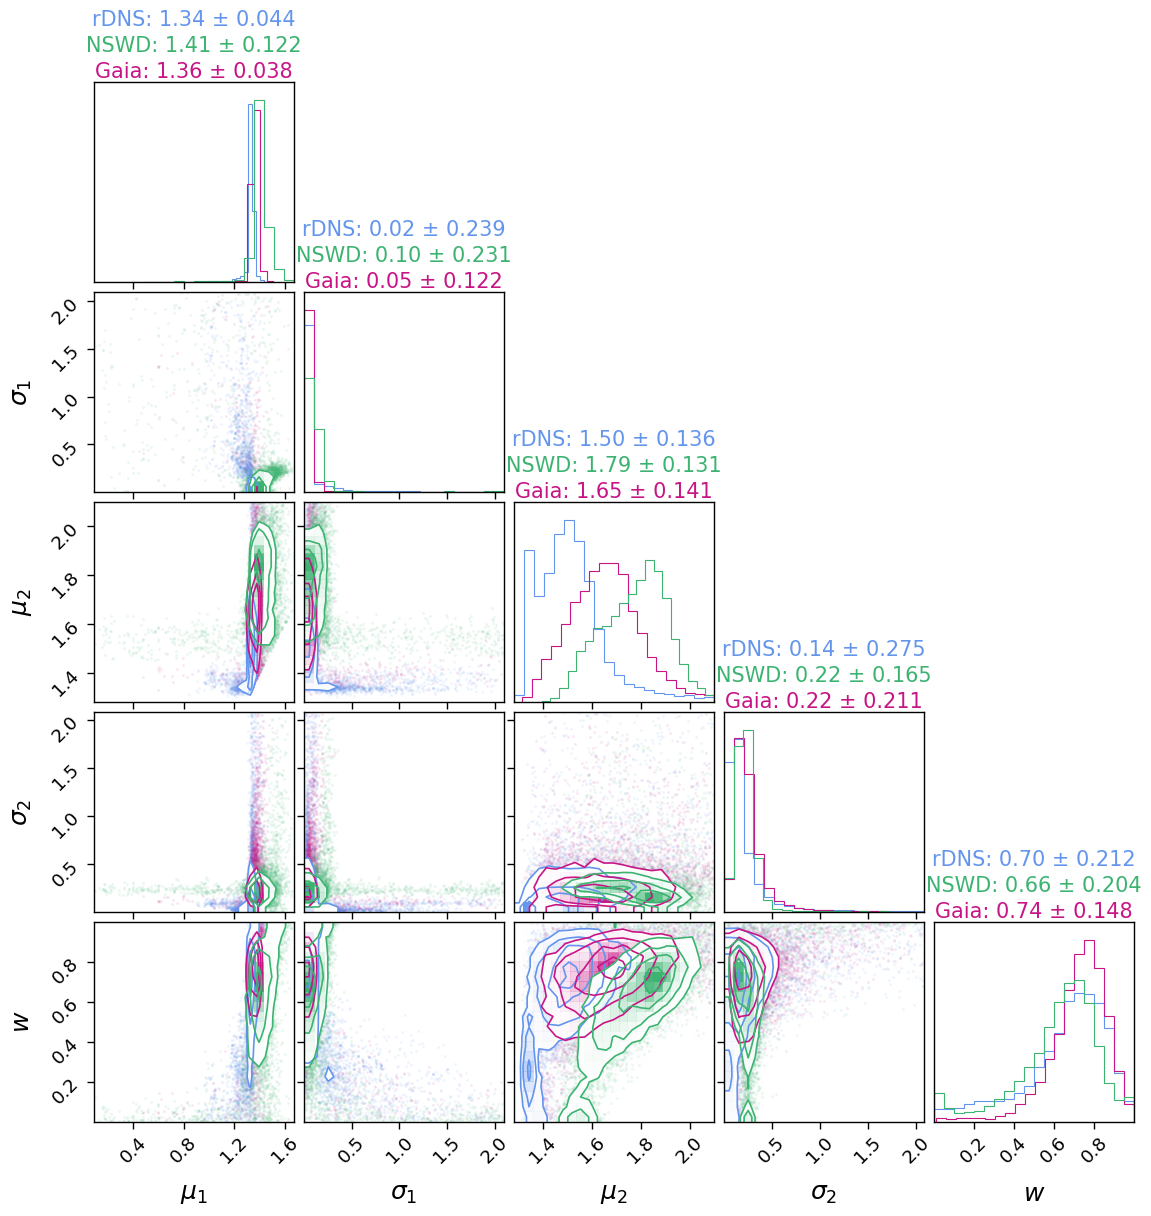

In [25]:
### Plot overlapping corner plots from different populations

# Variables
params = ['mu1', 'sigma1', 'mu2', 'sigma2', 'weight']
labels = [r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"]

fig = corner.corner(
    DNS_corner_samples,
    var_names=params,
    labels=labels,
    color='cornflowerblue',
    show_titles=False,
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    gaia_corner_samples,
    var_names=params,
    labels=labels,
    color='mediumvioletred',
    fig=fig,
    show_titles=False,
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    NSWD_corner_samples,
    var_names=params,
    labels=labels,
    color='mediumseagreen',
    fig=fig,
    show_titles=False,
    label_kwargs=dict(fontsize=18)
)

# Add in title manually
ndim = len(params)
axes = np.array(fig.axes).reshape((ndim, ndim))

for i, param in enumerate(params):
    ax = axes[i, i]

    # Compute summary stats
    median_dns = np.median(DNS_corner_samples.posterior[param])
    std_dns = np.std(DNS_corner_samples.posterior[param])
    median_nswd = np.median(NSWD_corner_samples[param])
    std_nswd = np.std(NSWD_corner_samples[param])
    median_gaia = np.median(gaia_corner_samples.posterior[param])
    std_gaia = np.std(gaia_corner_samples.posterior[param])

    # Add DNS title (top line)
    ax.text(0.5, 1.26,
            f"rDNS: {median_dns:.2f} ± {std_dns:.3f}",
            fontsize=15, color='cornflowerblue',
            ha='center', va='bottom', transform=ax.transAxes)
    
    # Add NSWD title 
    ax.text(0.5, 1.13,
            f"NSWD: {median_nswd:.2f} ± {std_nswd:.3f}",
            fontsize=15, color='mediumseagreen',
            ha='center', va='bottom', transform=ax.transAxes)

    # Add Gaia title
    ax.text(0.5, 1.00,
            f"Gaia: {median_gaia:.2f} ± {std_gaia:.3f}",
            fontsize=15, color='mediumvioletred',
            ha='center', va='bottom', transform=ax.transAxes)
plt.show()